In [229]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random

In [233]:
class LogisticFunction():
    def __init__(self, w, b):
        self.w = w
        self.b = b
        
    def solve(self, x: float) -> float:
        linear = self.w * x + self.b
        result_e = np.exp(-1 * linear)
        value = 1 / (1 + result_e)
        return float(value)

    def solve_from_z(self, z):
        result_e = np.exp(-1 * z)
        value = 1 / (1 + result_e)
        return value

    def get_w(self): return self.w
    def get_b(self): return self.b

    def set_w(self, w): self.w = w
    def set_b(self, b): self.b = b

[4.5397868702434395e-05, 0.00012339457598623172, 0.0003353501304664781, 0.0009110511944006454, 0.0024726231566347743, 0.0066928509242848554, 0.01798620996209156, 0.04742587317756678, 0.11920292202211755, 0.2689414213699951, 0.5, 0.7310585786300049, 0.8807970779778823, 0.9525741268224334, 0.9820137900379085, 0.9933071490757153, 0.9975273768433653, 0.9990889488055994, 0.9996646498695336, 0.9998766054240137]


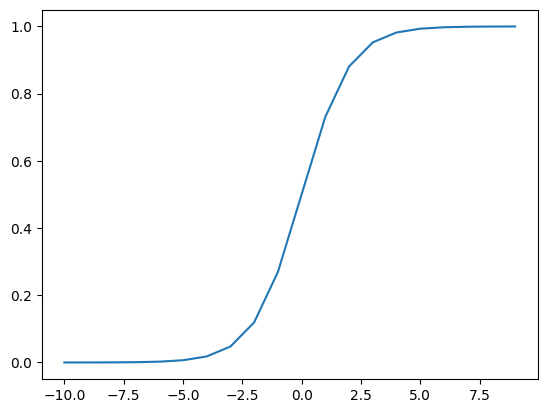

In [234]:
func = LogisticFunction(1.0, 0)
span = 20
x = [i-(span/2) for i in range(span)]
y = [func.solve(j) for j in x]

print(y)
plt.plot(x,y)

In [250]:
DATA_SIZE = 100
true = [[random.gauss(7, 3), 1] for i in range(DATA_SIZE)]
false = [[random.gauss(1, 3), 0] for i in range(DATA_SIZE)]

# combined = true + false
# random.shuffle(combined)
# dataset = combined

# alternative, faster numpy method
combined = true + false 
np_combined = np.array(combined)
permutation = np.random.permutation(len(np_true) + len(np_false))
dataset = np_combined[permutation]

In [236]:
def calculate_loss(predictions, answers):
    pc = np.clip(predictions, 1e-5, 1) # prediction clipped
    loss = -np.mean(answers * np.log(pc) + ((1 - answers) * np.log(1 - pc)))
    return float(loss)

In [237]:
def calculate_loss(predictions, answers):
    pc = np.clip(predictions, 1e-5, 1 - 1e-5) # prediction clipped
    loss = -np.mean(answers * np.log(pc) + ((1 - answers) * np.log(1 - pc)))
    return float(loss)
    
def eval(func: LogisticFunction):
    return np.mean([calculate_loss(func.solve(i[0]), i[1]) for i in dataset])

In [251]:
func = LogisticFunction(1, 0)

for step in range(400):
    X = dataset[step % len(dataset)][0]
    Y = dataset[step % len(dataset)][1]
    w = func.get_w()
    b = func.get_b()
    
    predictions = func.solve(X)
    
    # calculate the loss
    loss = calculate_loss(predictions, Y)
    
    grad_z = predictions - Y
    grad_w = X * grad_z
    grad_b = grad_z

    func.set_w(w - (grad_w * 0.0001))
    func.set_b(b - (grad_b * 0.0001))

print(eval(func))

1.0034247965745182


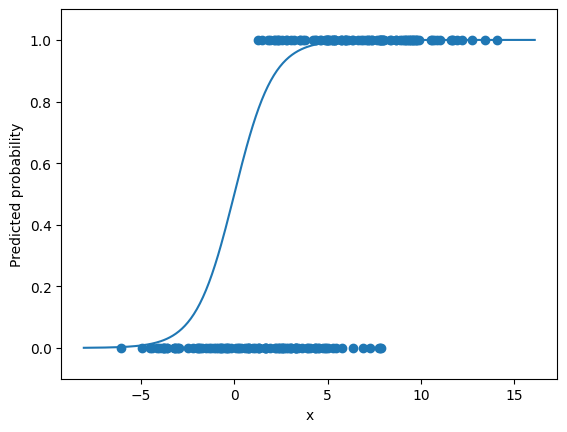

In [252]:
# now plot
# scatter the dataset
xs = [point[0] for point in dataset]
ys = [point[1] for point in dataset]

plt.scatter(xs, ys)

# generate smooth x-values across the dataset range
x_plot = np.linspace(min(xs) - 2, max(xs) + 2, 300)

# model predictions
y_plot = [func.solve(x) for x in x_plot]

plt.plot(x_plot, y_plot)

plt.xlabel("x")
plt.ylabel("Predicted probability")
plt.ylim(-0.1, 1.1)

plt.show()